## LIBRARIES

In [10]:
# IMPORT REQUIRED LIBRARIES
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis

## GENERATE 4-STAGE STRESS DATASET

In [11]:
np.random.seed(42)

# CASE 1: 100 TASKS - NORMAL STEADY IOT TRAFFIC
size_1 = np.random.lognormal(mean=0.5, sigma=0.5, size=100)
cpu_1 = np.random.gamma(shape=2.0, scale=10.0, size=100)

# CASE 2: 200 TASKS - ANOMALIES & OUTLIERS (HEAVY TAILS)
size_2 = np.random.lognormal(mean=1.5, sigma=1.5, size=200) 
cpu_2 = np.random.gamma(shape=4.0, scale=15.0, size=200)

# CASE 3: 300 TASKS - OVERWHELMING STRESS (MASSIVE SUSTAINED DEMAND)
size_3 = np.random.lognormal(mean=2.5, sigma=0.8, size=300)
cpu_3 = np.random.gamma(shape=6.0, scale=20.0, size=300)

# CASE 4: 400 TASKS - RAPID FLUCTUATIONS (MIX OF MICRO & MACRO TASKS)
size_4 = np.concatenate([np.random.lognormal(mean=0.1, sigma=0.2, size=200), 
                         np.random.lognormal(mean=2.5, sigma=1.0, size=200)])
cpu_4 = np.concatenate([np.random.gamma(shape=1.0, scale=5.0, size=200), 
                        np.random.gamma(shape=5.0, scale=25.0, size=200)])

### MERGE AND SCALE TO REALISTIC BOUNDS

In [12]:
raw_sizes = np.concatenate([size_1, size_2, size_3, size_4])
raw_cpus = np.concatenate([cpu_1, cpu_2, cpu_3, cpu_4])

task_sizes = 0.001 + (raw_sizes / raw_sizes.max()) * (500 - 0.001)
cpu_util = np.clip(raw_cpus, 1, 100)

### PREDICTED TIME

In [13]:
# SIMULATING THE ML ENGINE FOR ALL 1000 TASKS
exec_time_true = 0.02 * task_sizes + 0.3 * cpu_util + 5 + np.random.normal(0, 1.0, 1000)
exec_time_true = np.clip(exec_time_true, 0, 50)

df_test_cases = pd.DataFrame({
    "task_id": np.arange(1, 1001),
    "test_case": ["Case 1 (Normal)"]*100 + ["Case 2 (Outliers)"]*200 + ["Case 3 (Stress)"]*300 + ["Case 4 (Fluctuations)"]*400,
    "task_size_gb": task_sizes,
    "cpu_demand_units": cpu_util,
    "predicted_exec_time_ms": exec_time_true
})

## DEFINING THE ALGORITHMS

### GLOBAL PARAMETERS

In [14]:
# GLOBAL PARAMETERS
w_s, w_r, w_t = 0.4315, 0.4163, 0.1522
edge_capacity = 25
cloud_capacity = 50
window_size = 20
drain_rate_edge = 3   # TASKS PROCESSED BY EDGE PER WINDOW
drain_rate_cloud = 8  # TASKS PROCESSED BY CLOUD PER WINDOW

In [15]:
def safe_min_max_normalize(series):
    s_min, s_max = series.min(), series.max()
    return pd.Series([0.5] * len(series), index=series.index) if s_max == s_min else (series - s_min) / (s_max - s_min)

def process_queue_offload(target_tier, current_edge, current_cloud):
    """HANDLES QUEUE CAPACITY AND FALLBACK LOGIC"""
    stress, action = False, None
    if target_tier == "Edge":
        if current_edge >= edge_capacity:
            stress, target_tier, action = True, "Cloud", "EdgeFull_OffloadToCloud"
        else:
            return "Edge", current_edge + 1, current_cloud, stress, action
            
    if target_tier == "Cloud":
        if current_cloud >= cloud_capacity:
            return "StopOffloading", current_edge, current_cloud, True, "CloudFull_StopOffloading"
        else:
            return "Cloud", current_edge, current_cloud + 1, stress, action
            
    return target_tier, current_edge, current_cloud, stress, action

## DYNAMIC SML-OA

In [16]:
# --- ALGORITHM 1: DYNAMIC SML-OA (YOUR NOVELTY) ---
def run_sml_oa(df):
    log = []
    edge_q, cloud_q = 0, 0
    
    for start in range(0, len(df), window_size):
        win_df = df.iloc[start:start+window_size].copy()
        
        # DYNAMIC NORMALIZATION PER WINDOW
        win_df["s_norm"] = safe_min_max_normalize(win_df["task_size_gb"])
        win_df["r_norm"] = safe_min_max_normalize(win_df["cpu_demand_units"])
        win_df["t_norm"] = safe_min_max_normalize(win_df["predicted_exec_time_ms"])
        win_df["cos"] = (w_s * win_df["s_norm"] + w_r * win_df["r_norm"] + w_t * win_df["t_norm"]).round(4)
        
        q1 = np.percentile(win_df["cos"], 25, method='weibull')
        q3 = np.percentile(win_df["cos"], 75, method='weibull')
        iqr = q3 - q1
        kurt = kurtosis(win_df["cos"], fisher=False, bias=True)
        
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        
        for _, row in win_df.iterrows():
            cos_val = row["cos"]
            is_anomaly = (cos_val < lower or cos_val > upper) and kurt > 3.5
            
            stat_tier = "Cloud" if is_anomaly else ("IoT" if cos_val < q1 else ("Cloud" if cos_val > q3 else "Edge"))
            final_tier, edge_q, cloud_q, _, _ = process_queue_offload(stat_tier, edge_q, cloud_q)
            log.append(final_tier)
            
        # SIMULATE PROCESSING (DRAINING QUEUES AT END OF WINDOW)
        edge_q = max(0, edge_q - drain_rate_edge)
        cloud_q = max(0, cloud_q - drain_rate_cloud)
        
    return log

## STATIC COS

In [17]:
# --- ALGORITHM 2: STATIC COS (GLOBAL NORMALIZATION) ---
def run_static_cos(df):
    log = []
    edge_q, cloud_q = 0, 0
    
    # STATIC NORMALIZATION OVER ENTIRE 1000 DATASET
    df_stat = df.copy()
    df_stat["s_norm"] = safe_min_max_normalize(df_stat["task_size_gb"])
    df_stat["r_norm"] = safe_min_max_normalize(df_stat["cpu_demand_units"])
    df_stat["t_norm"] = safe_min_max_normalize(df_stat["predicted_exec_time_ms"])
    df_stat["cos"] = (w_s * df_stat["s_norm"] + w_r * df_stat["r_norm"] + w_t * df_stat["t_norm"]).round(4)
    
    q1 = np.percentile(df_stat["cos"], 25, method='weibull')
    q3 = np.percentile(df_stat["cos"], 75, method='weibull')
    
    for idx, row in df_stat.iterrows():
        cos_val = row["cos"]
        stat_tier = "IoT" if cos_val < q1 else ("Cloud" if cos_val > q3 else "Edge")
        final_tier, edge_q, cloud_q, _, _ = process_queue_offload(stat_tier, edge_q, cloud_q)
        log.append(final_tier)
        
        if (idx + 1) % window_size == 0:
            edge_q, cloud_q = max(0, edge_q - drain_rate_edge), max(0, cloud_q - drain_rate_cloud)
            
    return log

## SIZE-BASED STATIC THRESHOLD

In [18]:
# --- ALGORITHM 3: SIZE-BASED STATIC THRESHOLD ---
def run_size_based(df):
    log = []
    edge_q, cloud_q = 0, 0
    size_q1, size_q3 = df["task_size_gb"].quantile(0.25), df["task_size_gb"].quantile(0.75)
    
    for idx, row in df.iterrows():
        s_val = row["task_size_gb"]
        stat_tier = "IoT" if s_val < size_q1 else ("Cloud" if s_val > size_q3 else "Edge")
        final_tier, edge_q, cloud_q, _, _ = process_queue_offload(stat_tier, edge_q, cloud_q)
        log.append(final_tier)
        
        if (idx + 1) % window_size == 0:
            edge_q, cloud_q = max(0, edge_q - drain_rate_edge), max(0, cloud_q - drain_rate_cloud)
            
    return log

## RUN AND COMPILE RESULTS

In [19]:
res_sml = run_sml_oa(df_test_cases)
res_static_cos = run_static_cos(df_test_cases)
res_size = run_size_based(df_test_cases)

df_results = pd.DataFrame({
    "test_case": df_test_cases["test_case"],
    "sml_oa_dynamic": res_sml,
    "static_cos": res_static_cos,
    "size_based_static": res_size
})

## SUCCESS RATES

In [20]:
# CALCULATE SUCCESS RATES (TASKS NOT DROPPED)
def calc_success_rate(series):
    return 100 * (1 - (series == "StopOffloading").sum() / len(series))

success_rates = {
    "SML-OA (Dynamic)": calc_success_rate(df_results["sml_oa_dynamic"]),
    "Static COS": calc_success_rate(df_results["static_cos"]),
    "Size-Based Static": calc_success_rate(df_results["size_based_static"])
}

## COMPARATIVE DASHBOARD & PLOTS

### SUCCESS RATE COMPARISON

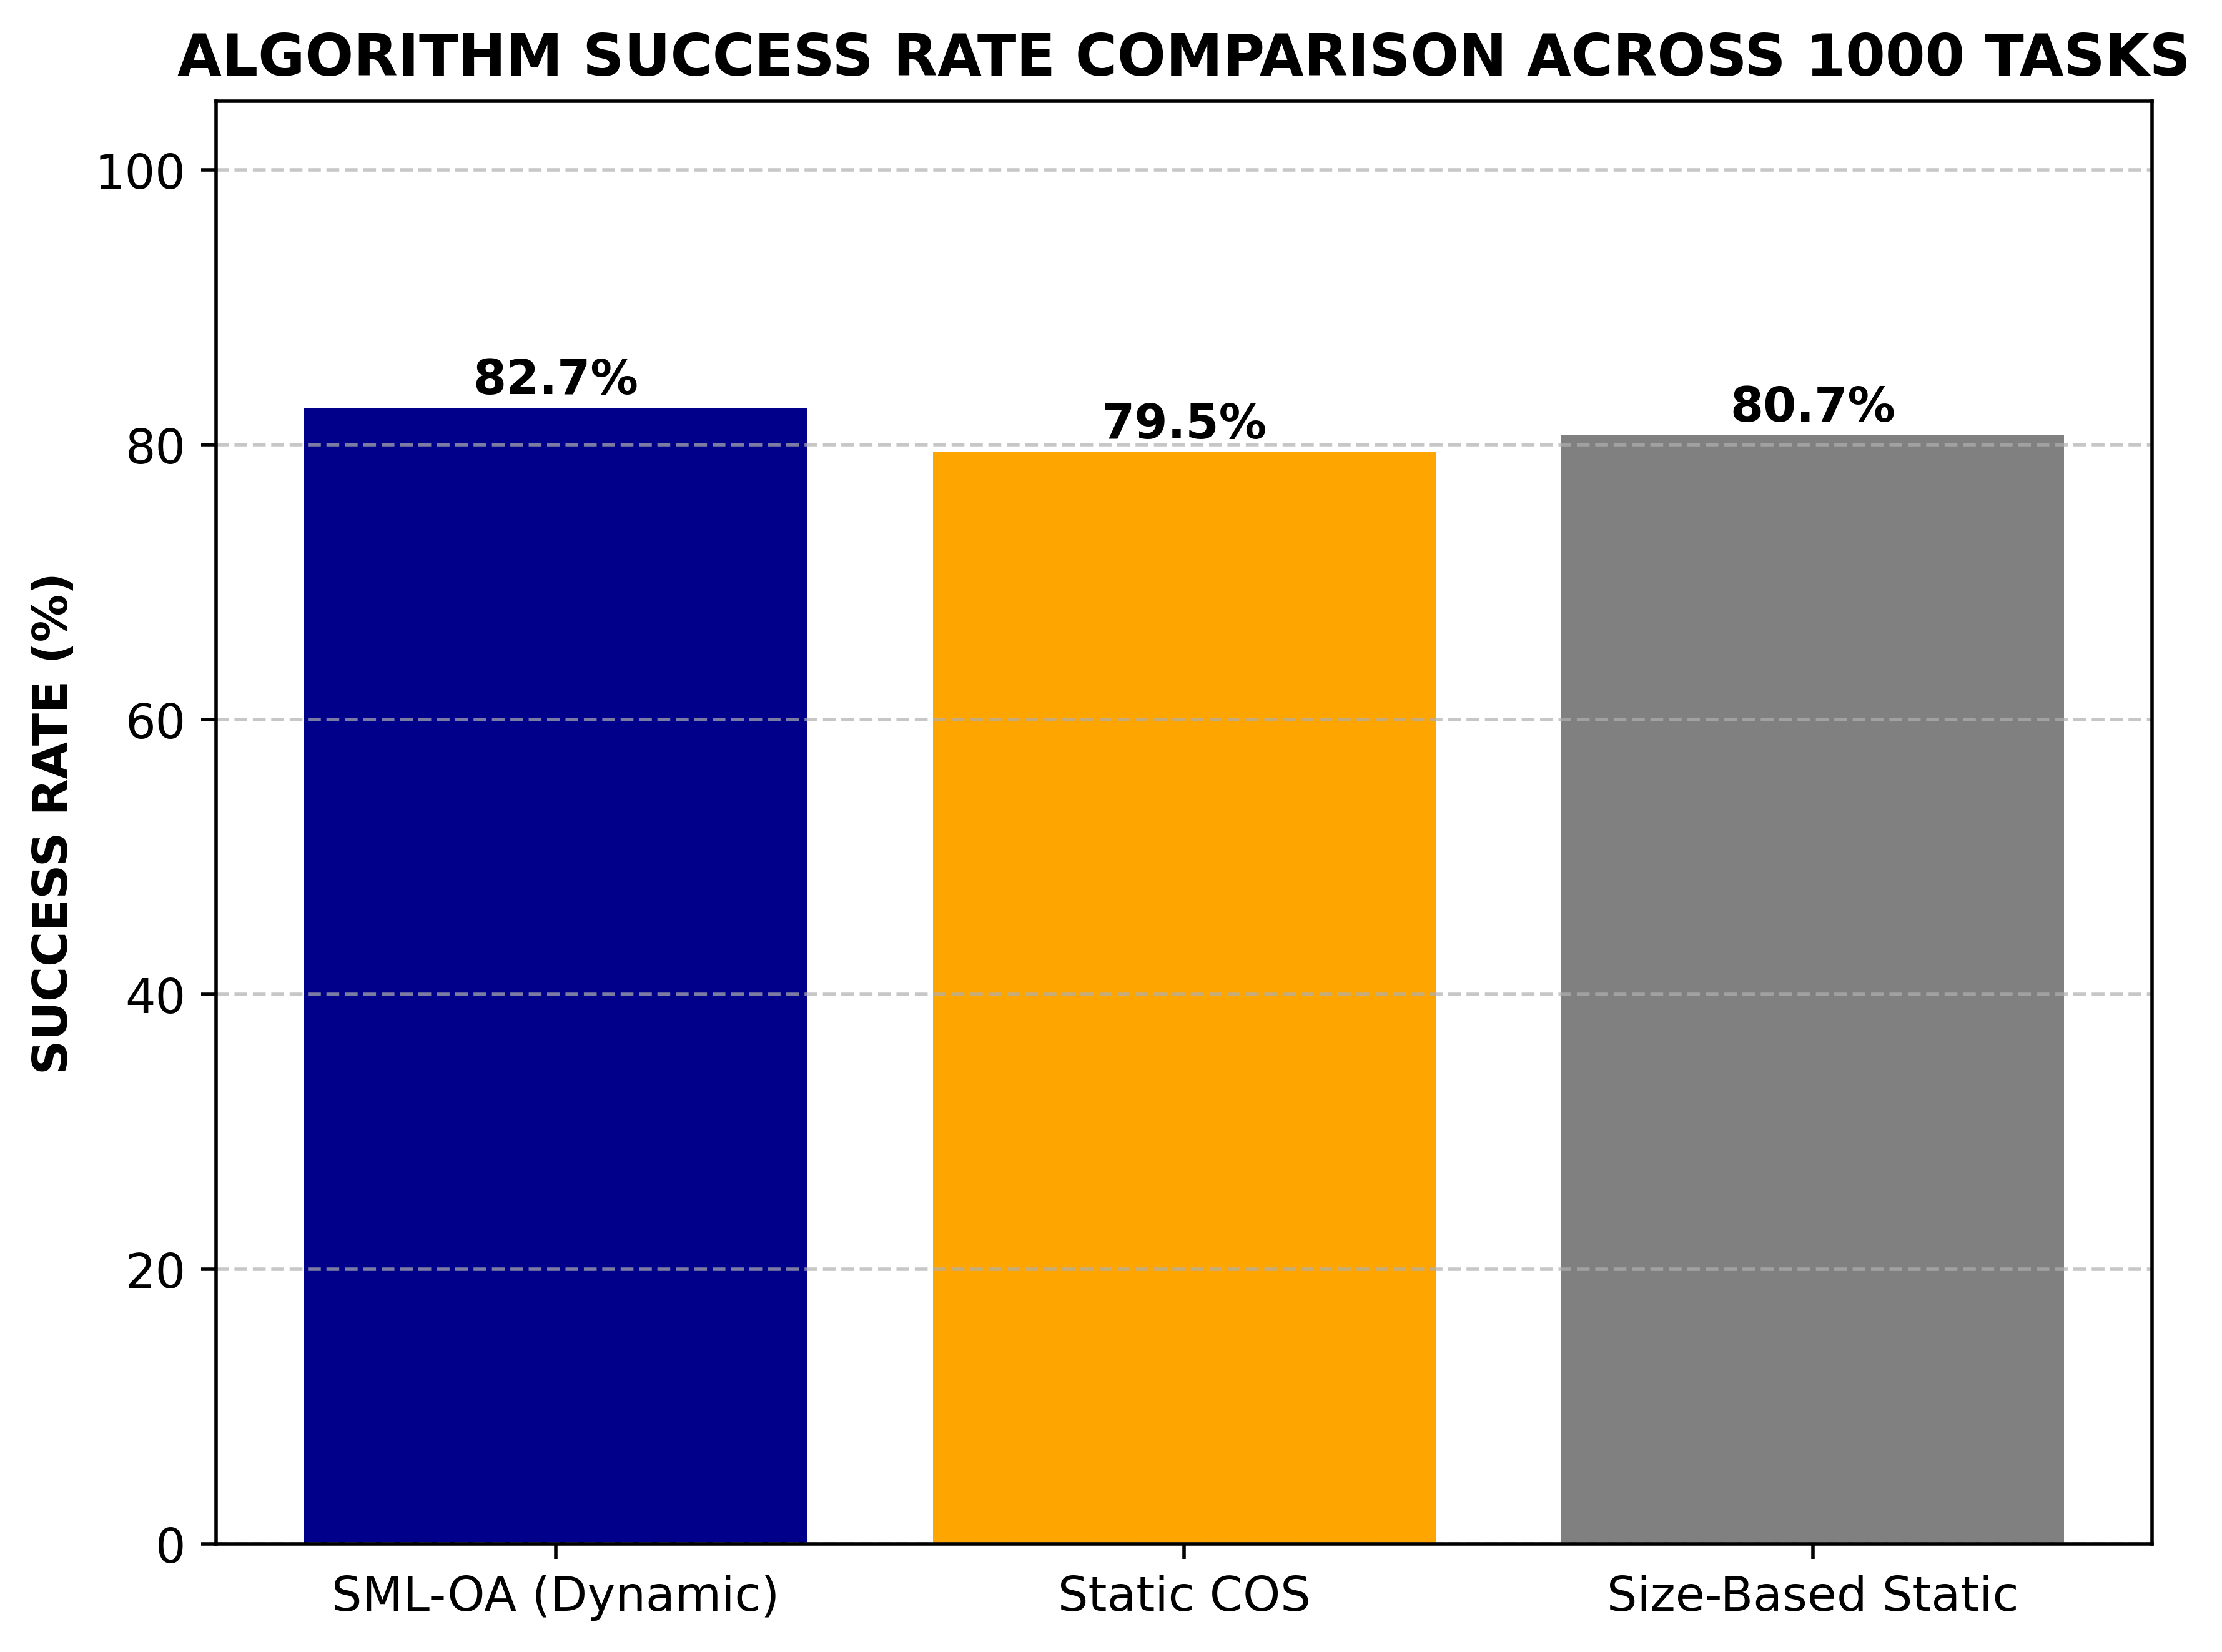

In [30]:
plt.rcParams.update({"font.size": 11, "axes.labelweight": "bold", "axes.titleweight": "bold"})
plt.figure(figsize=(8, 6), dpi=500)
bars = plt.bar(success_rates.keys(), success_rates.values(), color=['darkblue', 'orange', 'gray'])
plt.title("ALGORITHM SUCCESS RATE COMPARISON ACROSS 1000 TASKS")
plt.ylabel("SUCCESS RATE (%)")
plt.ylim(0, 105)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f"{yval:.1f}%", ha='center', fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### TIER ALLOCATION BREAKDOWN

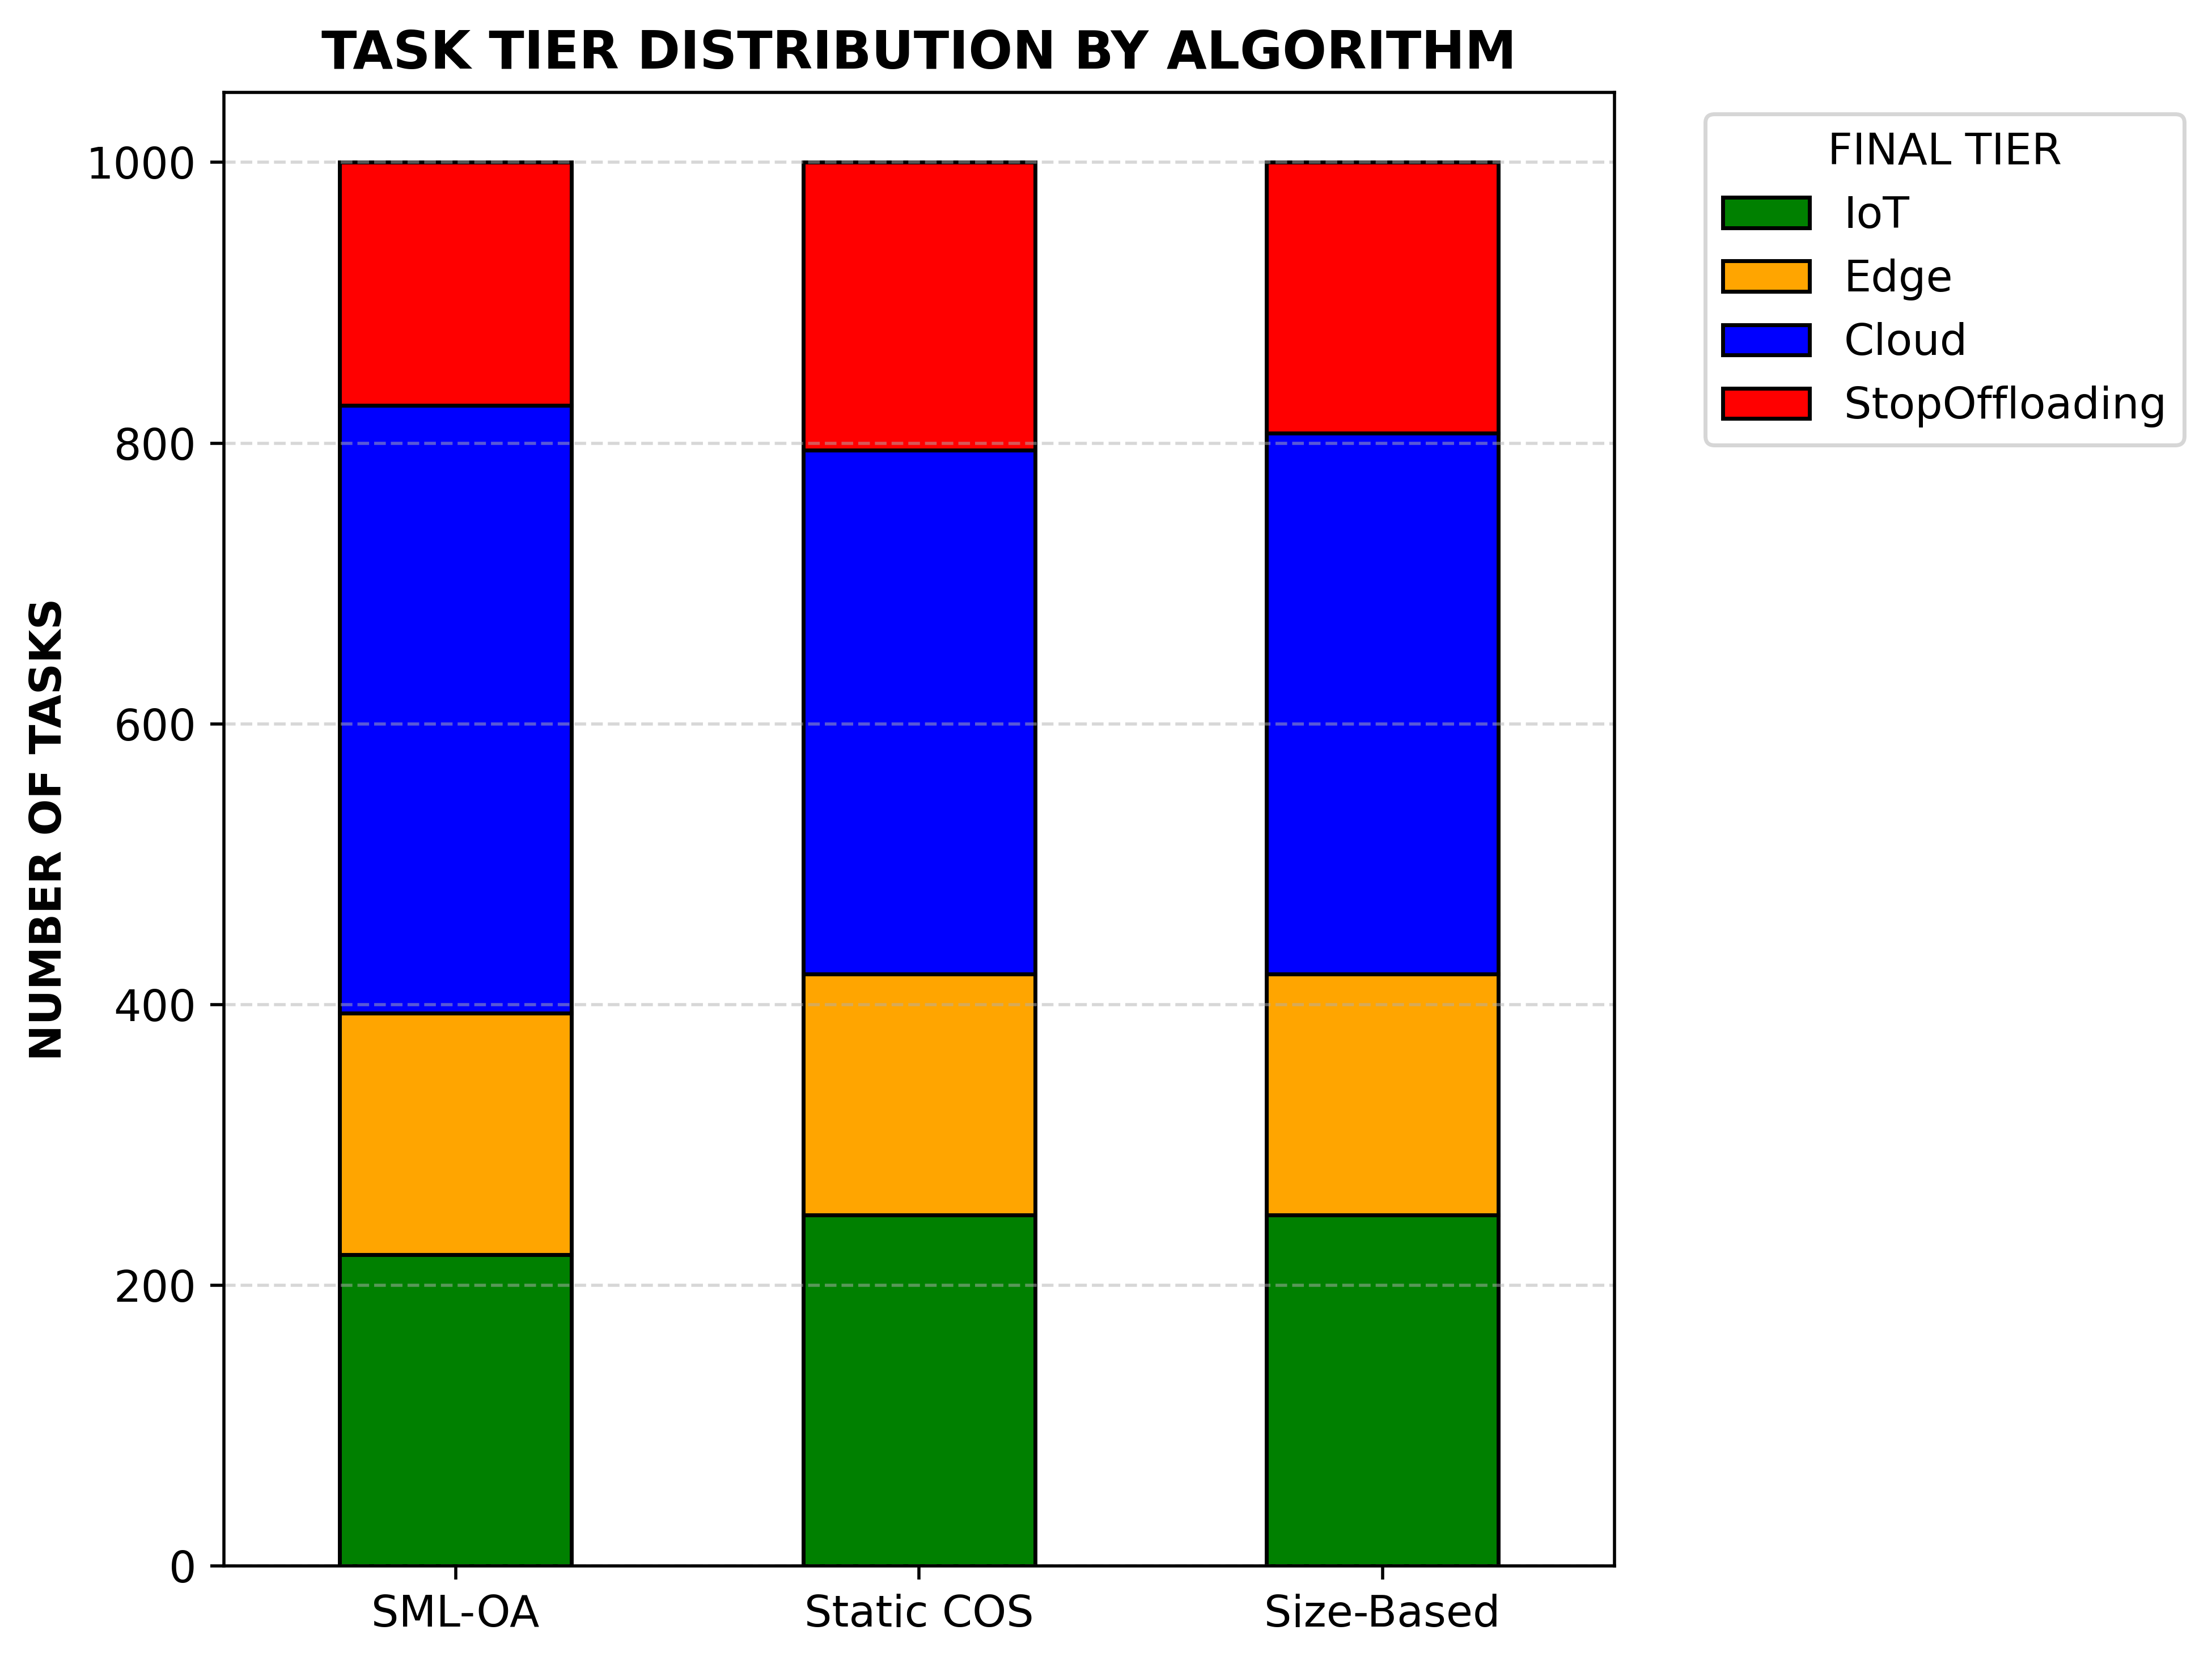

In [40]:
# TIER ALLOCATION BREAKDOWN (STACKED BAR)

algos = ["sml_oa_dynamic", "static_cos", "size_based_static"]
labels = ["SML-OA", "Static COS", "Size-Based"]
tiers = ["IoT", "Edge", "Cloud", "StopOffloading"]
colors = ["green", "orange", "blue", "red"]

alloc_data = {alg: [df_results[df_results[alg] == t].shape[0] for t in tiers] for alg in algos}
df_alloc = pd.DataFrame(alloc_data, index=tiers).T

# Create figure with high DPI
fig, ax = plt.subplots(figsize=(8, 6), dpi=500)

# Plot on the created axis
df_alloc.plot(kind='bar', stacked=True, color=colors, edgecolor='black', ax=ax)

ax.set_title("TASK TIER DISTRIBUTION BY ALGORITHM")
ax.set_ylabel("NUMBER OF TASKS")
ax.set_xticks(range(3))
ax.set_xticklabels(labels, rotation=0)

ax.legend(title="FINAL TIER", bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### FAILURE RATE ACROSS DIFFERENT STRESS CASES

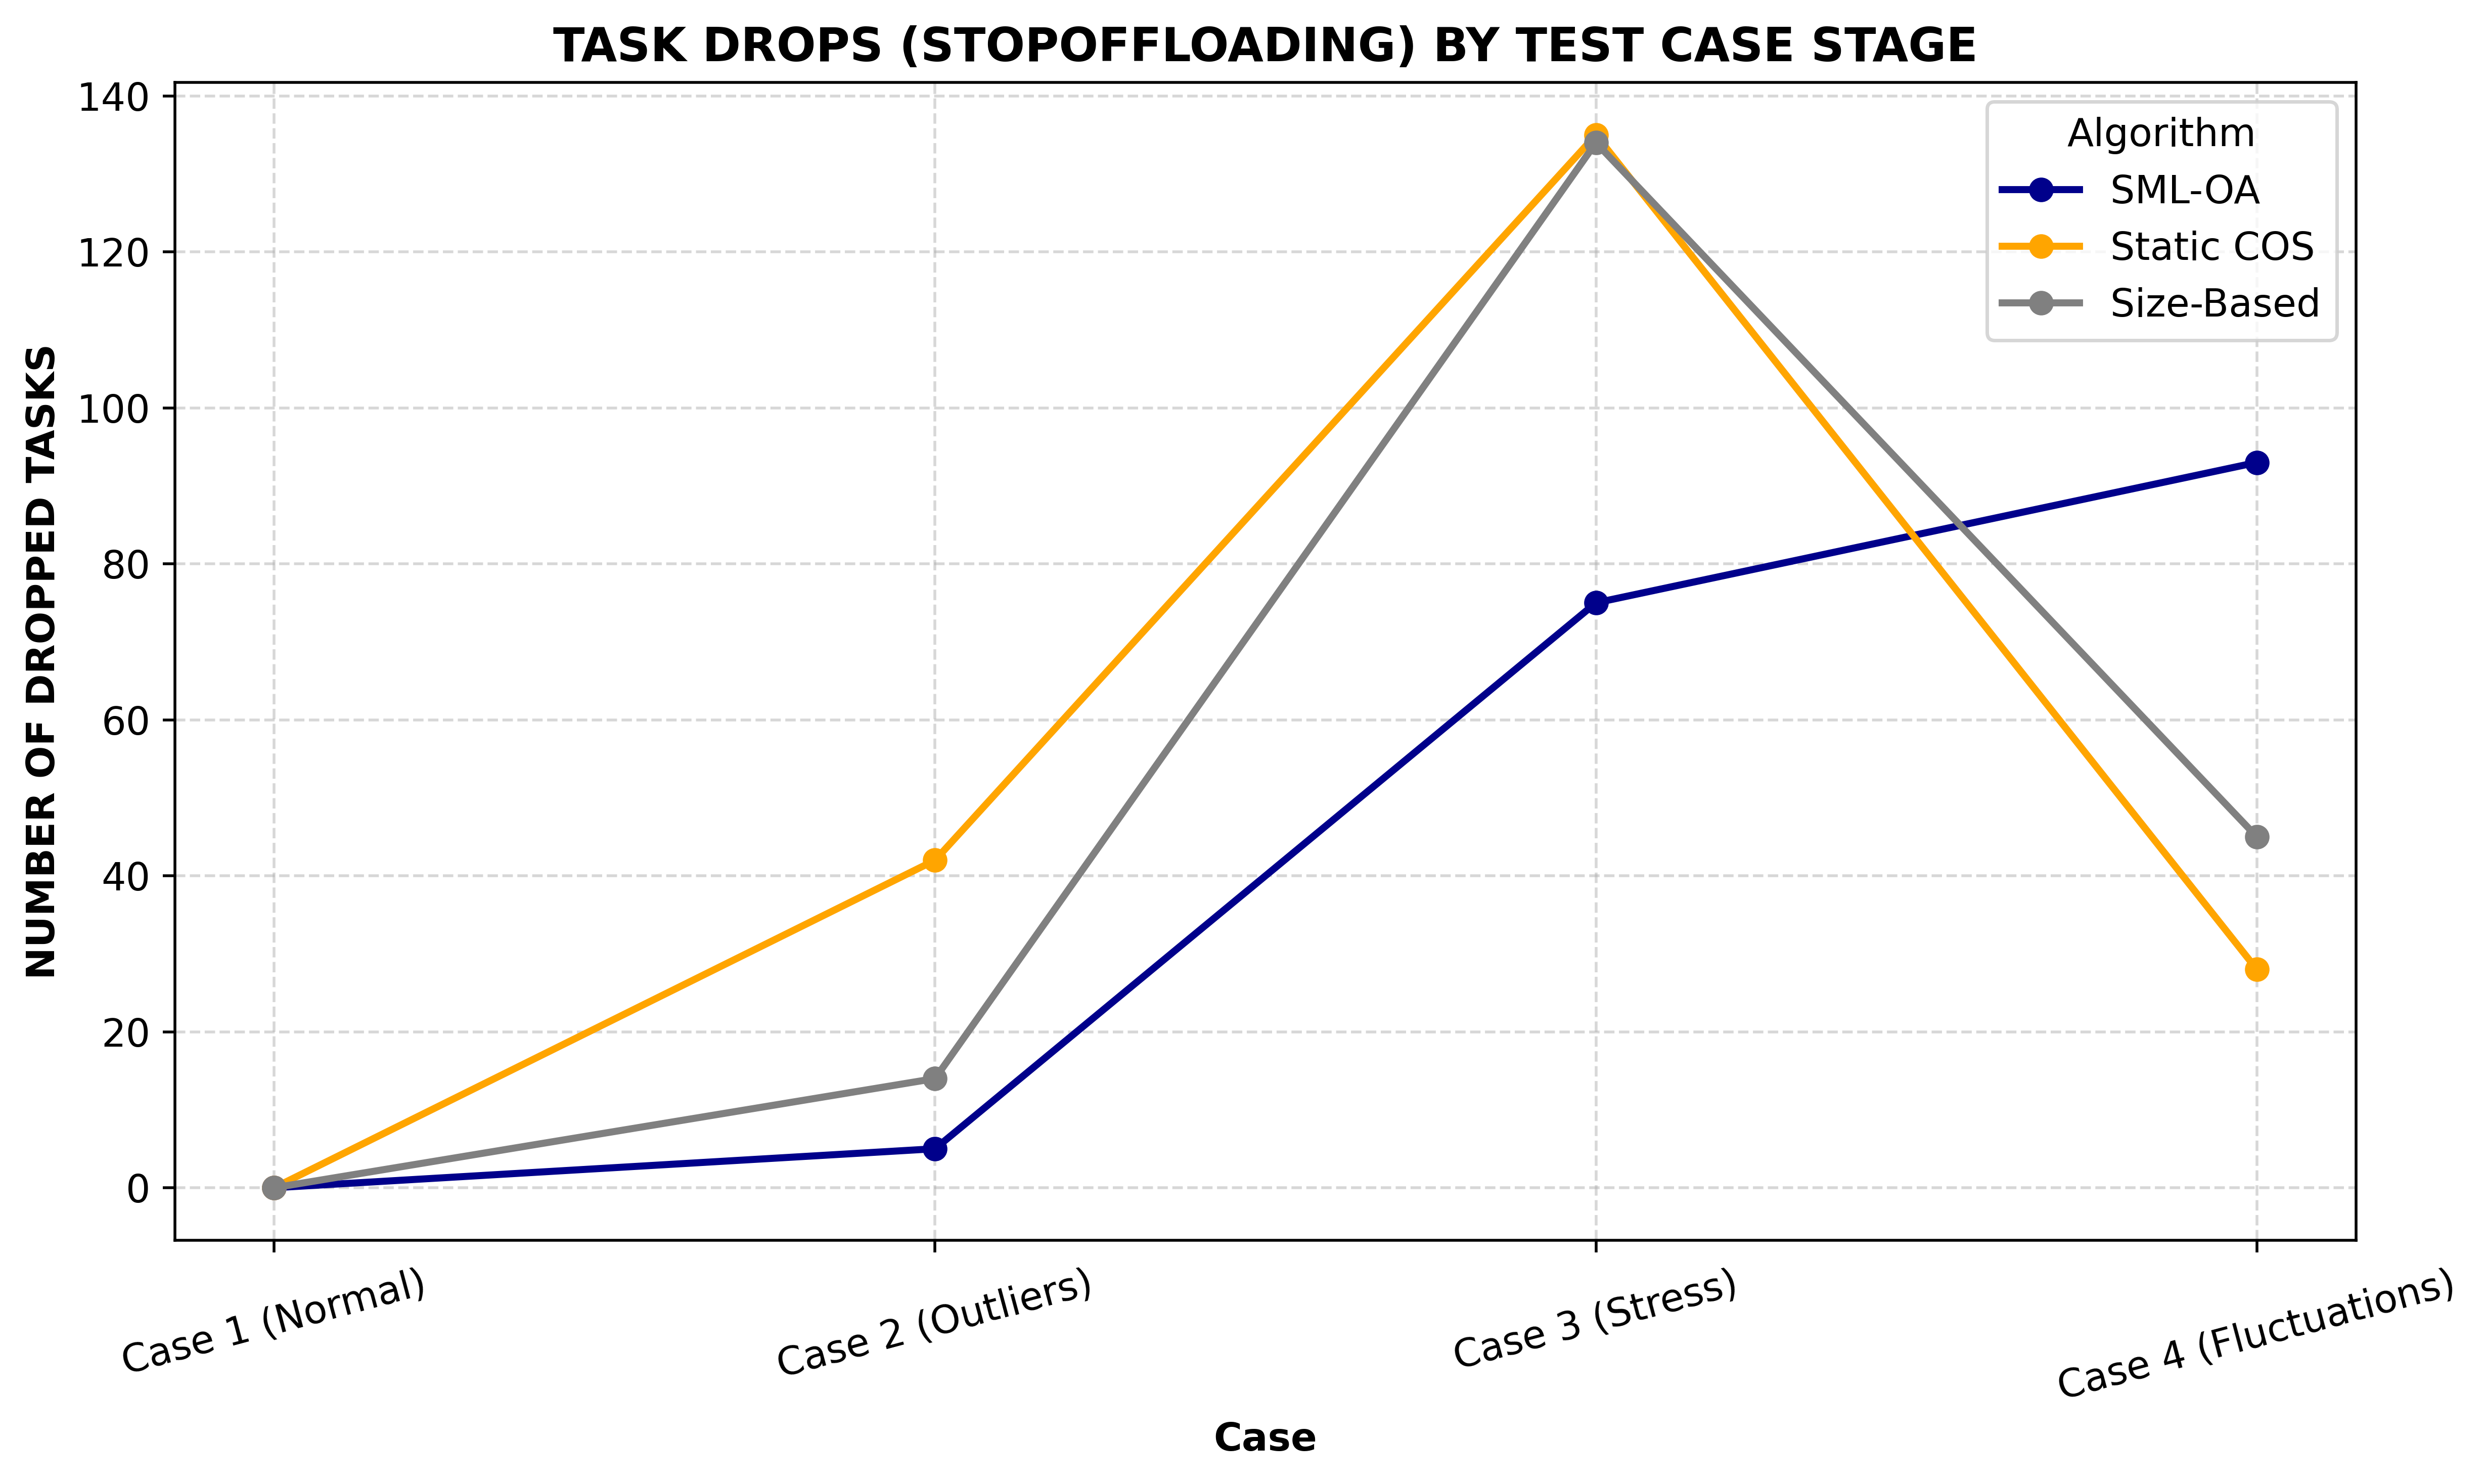

In [41]:
failure_data = []
for case in df_results["test_case"].unique():
    subset = df_results[df_results["test_case"] == case]
    failure_data.append({
        "Case": case,
        "SML-OA": (subset["sml_oa_dynamic"] == "StopOffloading").sum(),
        "Static COS": (subset["static_cos"] == "StopOffloading").sum(),
        "Size-Based": (subset["size_based_static"] == "StopOffloading").sum()
    })

df_fails = pd.DataFrame(failure_data).set_index("Case")

# Create high-resolution figure
fig, ax = plt.subplots(figsize=(10, 6), dpi=500)

# Plot using the axis
df_fails.plot(
    kind='line',
    marker='o',
    linewidth=2,
    color=['darkblue', 'orange', 'gray'],
    ax=ax
)

ax.set_title("TASK DROPS (STOPOFFLOADING) BY TEST CASE STAGE")
ax.set_ylabel("NUMBER OF DROPPED TASKS")
ax.set_xticks(range(len(df_fails.index)))
ax.set_xticklabels(df_fails.index, rotation=15)

ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(title="Algorithm")

plt.tight_layout()
plt.show()